# Friedel Test Dataset Builder

This notebook builds one manual test sample at a time using:

- one overlapping input spot from an input frame
- two explicitly chosen Friedel partner spots from exact partner frames
- the two partner intensities and masks as ground truth

The workflow is split into two parts: first inspect all numbered spots on the relevant frames, then choose the exact spot numbers for the sample.


In [1]:
from pathlib import Path
from collections import deque

import h5py
try:
    import hdf5plugin  # noqa: F401
except ImportError:
    hdf5plugin = None
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle


DATA_ROOT = Path("../../data_esrf")
DATASETS = {
    "Al": {"main": "_iris_iris_500_cont.h5"},
    "Al_big_grains": {"main": "Al1050_dct7p5_Al1050_dct7p.h5"},
    "Al_deformed_LoG": {"main": "A2050_as_annealed_DT_W370_0p12_strain_dct3_A2050_as_annealed_DT_W370_0p12_strain_dct.h5"},
    "Al_small_grains": {"main": "iris_dct_450C_0003_iris_dct_450C.h5"},
    "Cu": {"main": "copper3_dct_load1_redo_copper3_dct_load1_redo.h5"},
    "IN718_twins": {"main": "ep_sync_12_dct_7p5_3_ep_sync_12_dct_7p5.h5"},
    "Iron": {"main": "ind_Iron_dct_load1_z1_ind_Iron_dct_load1_z.h5"},
    "Iron_deformed": {"main": "pureIron2_dct_2nd_load_z1_pureIron2_dct_2nd_load_z.h5"},
    "Ti7Al": {"main": "sam_23_dct4_sam_23_dct.h5"},
}

RAW_KEY = "instrument/detector_0/data"
SEG_KEY = "segvol"
CROP_SIZE = 128
MIN_PIXELS = 3
MAX_LABELED_SPOTS = 300
DISPLAY_ROTATE_K = 0  # extra 90 degree turn applied after the raw/seg alignment fix
FLIP_GROUND_TRUTH_HORIZONTALLY = True
BLACK_OUT_INPUT_BACKGROUND = True
BLACK_OUT_TARGET_BACKGROUND = True
NORMALIZE_INTENSITY_WITH_MASK = True
RESIZE_OVERSIZED_SPOTS = True
FIT_MARGIN_FRACTION = 0.7  # input crops use this fit fraction inside the 128x128 frame
TARGET_FIT_MARGIN_FRACTION = 0.4  # lower values make only the Friedel target spots smaller
JOINT_NORMALIZATION_SCOPE = "sample"  # sample: input + all targets share one scale
USE_BACKGROUND_SUBTRACTION = False
MIN_MASK_INTENSITY = 0.0
ALIGN_GROUND_TRUTH_TO_INPUT = True
PREVIEW_INTERPOLATION = "nearest"
PREVIEW_COLORMAP = "gray"
PREVIEW_BACKGROUND_MODE = "export"  # raw | masked_raw | export
PAD_TARGETS_TO_COUNT = 2  # append all-black placeholder targets until this count is reached

SCAN = "IN718_twins"

EXPORT_DIR = Path("../data/test_friedel_crops")
PREVIEW_PDF_DIR = EXPORT_DIR / "preview_pdfs"
SAVE_PREVIEW_PDF = True

def scan_paths(scan: str) -> tuple[Path, Path]:
    scan_dir = DATA_ROOT / scan
    raw_path = scan_dir / DATASETS[scan]["main"]
    seg_path = scan_dir / "segvol.h5"
    if not raw_path.exists():
        raise FileNotFoundError(f"Raw file not found: {raw_path}")
    if not seg_path.exists():
        raise FileNotFoundError(f"Seg file not found: {seg_path}")
    return raw_path, seg_path


RAW_PATH, SEG_PATH = scan_paths(SCAN)
print(f"Scan       : {SCAN}")
print(f"Raw path   : {RAW_PATH}")
print(f"Seg path   : {SEG_PATH}")
print(f"Crop size  : {CROP_SIZE} x {CROP_SIZE}")
print(f"Display rot: {DISPLAY_ROTATE_K} (np.rot90 after alignment)")
print(f"GT flip LR : {FLIP_GROUND_TRUTH_HORIZONTALLY}")
print(f"Input mask : {BLACK_OUT_INPUT_BACKGROUND}")
print(f"Target bk  : {BLACK_OUT_TARGET_BACKGROUND}")
print(f"Norm inten.: {NORMALIZE_INTENSITY_WITH_MASK}")
print(f"Bg subtract: {USE_BACKGROUND_SUBTRACTION}")
print(f"Norm scope : {JOINT_NORMALIZATION_SCOPE}")
print(f"Input fit  : {FIT_MARGIN_FRACTION}")
print(f"Target fit : {TARGET_FIT_MARGIN_FRACTION}")
print(f"Pad targets: {PAD_TARGETS_TO_COUNT}")
print(f"Save PDFs  : {SAVE_PREVIEW_PDF}")
print(f"Preview dir: {PREVIEW_PDF_DIR}")
print(f"Mask floor : {MIN_MASK_INTENSITY}")
print(f"Align GT   : {ALIGN_GROUND_TRUTH_TO_INPUT}")
print(f"Preview    : mode={PREVIEW_BACKGROUND_MODE}, interp={PREVIEW_INTERPOLATION}, cmap={PREVIEW_COLORMAP}")


Scan       : IN718_twins
Raw path   : ../../data_esrf/IN718_twins/ep_sync_12_dct_7p5_3_ep_sync_12_dct_7p5.h5
Seg path   : ../../data_esrf/IN718_twins/segvol.h5
Crop size  : 128 x 128
Display rot: 0 (np.rot90 after alignment)
GT flip LR : True
Input mask : True
Target bk  : True
Norm inten.: True
Bg subtract: False
Norm scope : sample
Input fit  : 0.7
Target fit : 0.4
Pad targets: 2
Save PDFs  : True
Preview dir: ../data/test_friedel_crops/preview_pdfs
Mask floor : 0.0
Align GT   : True
Preview    : mode=export, interp=nearest, cmap=gray


In [2]:
def raw_base_orientation(frame: np.ndarray) -> np.ndarray:
    # Keep raw detector pixels in their native orientation so they match spot_browser.
    return frame

def seg_base_orientation(frame: np.ndarray) -> np.ndarray:
    # This matched the raw orientation in spot_browser/previous notebook versions.
    return np.rot90(frame[::-1], k=-1)


def orient_raw_frame(frame: np.ndarray) -> np.ndarray:
    return np.rot90(raw_base_orientation(frame), k=DISPLAY_ROTATE_K)


def orient_seg_frame(frame: np.ndarray) -> np.ndarray:
    return np.rot90(seg_base_orientation(frame), k=DISPLAY_ROTATE_K)


def focused_seg_display(frame: np.ndarray) -> tuple[np.ndarray, 
mcolors.Colormap, float, float]:
    display = np.where(frame > 0, 0.35, 1.0).astype(np.float32)
    return display, plt.cm.gray, 0.0, 1.0


def load_raw_frame(frame_idx: int) -> np.ndarray:
    with h5py.File(RAW_PATH, "r") as f:
        frame = np.asarray(f[RAW_KEY][int(frame_idx)])
    return orient_raw_frame(frame)


def load_seg_frame(frame_idx: int) -> np.ndarray:
    with h5py.File(SEG_PATH, "r") as f:
        frame = np.asarray(f[SEG_KEY][int(frame_idx)])
    return orient_seg_frame(frame)


def connected_components(binary: np.ndarray) -> list[np.ndarray]:
    coords = set(map(tuple, np.argwhere(binary)))
    components = []
    neighbors = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1),
    ]
    while coords:
        start = coords.pop()
        queue = deque([start])
        pixels = [start]
        while queue:
            r, c = queue.popleft()
            for dr, dc in neighbors:
                nxt = (r + dr, c + dc)
                if nxt in coords:
                    coords.remove(nxt)
                    queue.append(nxt)
                    pixels.append(nxt)
        components.append(np.asarray(pixels, dtype=np.int32))
    return sorted(components, key=len, reverse=True)


def component_records(seg_frame: np.ndarray, min_pixels: int = MIN_PIXELS) -> list[dict]:
    records = []
    for comp in connected_components(seg_frame > 0):
        if len(comp) < min_pixels:
            continue
        rows = comp[:, 0]
        cols = comp[:, 1]
        r0, r1 = int(rows.min()), int(rows.max()) + 1
        c0, c1 = int(cols.min()), int(cols.max()) + 1
        mask = np.zeros((r1 - r0, c1 - c0), dtype=np.uint8)
        mask[rows - r0, cols - c0] = 1
        records.append(
            {
                "spot_number": len(records),
                "pixels": int(len(comp)),
                "bbox": (r0, c0, r1, c1),
                "centroid_rc": np.array([rows.mean(), cols.mean()], dtype=np.float32),
                "mask_local": mask,
            }
        )
        if len(records) >= MAX_LABELED_SPOTS:
            break
    return records


def record_by_spot_number(records: list[dict], spot_number: int) -> dict:
    for record in records:
        if int(record["spot_number"]) == int(spot_number):
            return record
    raise KeyError(f"spot_number={spot_number} not found")


def crop_around(frame: np.ndarray, center_rc: np.ndarray, size: int = CROP_SIZE, fill_value: float = 0.0) -> np.ndarray:
    size = int(size)
    half = size // 2
    r_center = int(round(float(center_rc[0])))
    c_center = int(round(float(center_rc[1])))
    r0 = r_center - half
    c0 = c_center - half
    r1 = r0 + size
    c1 = c0 + size

    src_r0 = max(r0, 0)
    src_c0 = max(c0, 0)
    src_r1 = min(r1, frame.shape[0])
    src_c1 = min(c1, frame.shape[1])

    out = np.full((size, size), fill_value, dtype=frame.dtype)
    dst_r0 = src_r0 - r0
    dst_c0 = src_c0 - c0
    dst_r1 = dst_r0 + (src_r1 - src_r0)
    dst_c1 = dst_c0 + (src_c1 - src_c0)
    out[dst_r0:dst_r1, dst_c0:dst_c1] = frame[src_r0:src_r1, src_c0:src_c1]
    return out


def resize_square_nearest(array: np.ndarray, out_size: int) -> np.ndarray:
    out_size = int(out_size)
    if array.shape == (out_size, out_size):
        return array.copy()
    if out_size <= 0:
        raise ValueError(f"out_size must be positive, got {out_size}")

    row_idx = np.clip(np.rint(np.linspace(0, array.shape[0] - 1, out_size)), 0, array.shape[0] - 1).astype(np.int32)
    col_idx = np.clip(np.rint(np.linspace(0, array.shape[1] - 1, out_size)), 0, array.shape[1] - 1).astype(np.int32)
    return array[row_idx[:, None], col_idx[None, :]].copy()

def resolve_fit_margin_fraction(fit_margin_fraction: float | None = None) -> float:
    value = FIT_MARGIN_FRACTION if fit_margin_fraction is None else fit_margin_fraction
    return float(np.clip(value, 0.1, 1.0))


def resize_source_crop_size(bbox: tuple[int, int, int, int], crop_size: int = CROP_SIZE, fit_margin_fraction: float | None = None) -> int:
    crop_size = int(crop_size)
    r0, c0, r1, c1 = bbox
    bbox_h = max(int(r1) - int(r0), 1)
    bbox_w = max(int(c1) - int(c0), 1)
    if not RESIZE_OVERSIZED_SPOTS:
        return crop_size
    fit_fraction = resolve_fit_margin_fraction(fit_margin_fraction)
    return max(crop_size, int(np.ceil(bbox_h / fit_fraction)), int(np.ceil(bbox_w / fit_fraction)))


def maybe_resize_crop_to_fit(raw_crop: np.ndarray, mask_crop: np.ndarray, bbox: tuple[int, int, int, int], crop_size: int = CROP_SIZE, fit_margin_fraction: float | None = None) -> tuple[np.ndarray, np.ndarray, bool, int]:
    crop_size = int(crop_size)
    r0, c0, r1, c1 = bbox
    bbox_h = max(int(r1) - int(r0), 1)
    bbox_w = max(int(c1) - int(c0), 1)
    fit_fraction = resolve_fit_margin_fraction(fit_margin_fraction)
    effective_target = max(1, int(np.floor(crop_size * fit_fraction)))
    source_size = int(raw_crop.shape[0])
    if (not RESIZE_OVERSIZED_SPOTS) or max(bbox_h, bbox_w) <= effective_target:
        return raw_crop, mask_crop, False, source_size

    resized_raw = resize_square_nearest(raw_crop.astype(np.float32, copy=False), crop_size).astype(np.float32, copy=False)
    resized_mask = (resize_square_nearest(mask_crop.astype(np.uint8, copy=False), crop_size) > 0).astype(np.uint8, copy=False)
    return resized_raw, resized_mask, True, source_size

def full_mask_from_record(shape: tuple[int, int], record: dict) -> np.ndarray:
    full = np.zeros(shape, dtype=np.uint8)
    r0, c0, r1, c1 = record["bbox"]
    full[r0:r1, c0:c1] = record["mask_local"]
    return full


def masked_spot_intensity(raw_crop: np.ndarray, mask_crop: np.ndarray) -> np.ndarray:
    raw_crop = raw_crop.astype(np.float32, copy=False)
    signal = raw_crop.copy()
    if USE_BACKGROUND_SUBTRACTION:
        background = raw_crop[mask_crop == 0]
        baseline = float(np.median(background)) if background.size else 0.0
        signal -= baseline
    signal[signal < 0] = 0.0
    signal[mask_crop == 0] = 0.0
    return signal.astype(np.float32, copy=False)


def erode_mask(mask: np.ndarray, iterations: int = 1) -> np.ndarray:
    current = (mask > 0).astype(np.uint8, copy=False)
    for _ in range(max(int(iterations), 0)):
        if int(current.sum()) <= 9:
            break
        padded = np.pad(current, 1, mode="constant", constant_values=0)
        neighborhoods = [
            padded[r:r + current.shape[0], c:c + current.shape[1]]
            for r in range(3) for c in range(3)
        ]
        eroded = np.logical_and.reduce(neighborhoods).astype(np.uint8)
        if int(eroded.sum()) == 0:
            break
        current = eroded
    return current.astype(np.uint8, copy=False)


def robust_limits(array: np.ndarray, lower: float = 1.0, upper: float = 99.8, positive_only: bool = True) -> tuple[float, float]:
    values = np.asarray(array)[np.isfinite(array)]
    if positive_only:
        values = values[values > 0]
    if values.size == 0:
        return 0.0, 1.0
    vmin, vmax = np.percentile(values, [lower, upper])
    if vmax <= vmin:
        vmin, vmax = float(values.min()), float(values.max())
    if vmax <= vmin:
        vmax = vmin + 1.0
    return float(vmin), float(vmax)


def preview_intensity_panel(crop: dict, mode: str = PREVIEW_BACKGROUND_MODE):
    mode = str(mode)
    preview_mask = crop.get("preview_mask", crop["mask"]).astype(np.uint8, copy=False)
    preview_raw = crop.get("preview_raw", crop["raw"]).astype(np.float32, copy=False)
    preview_image = crop.get("preview_image", crop.get("image", crop["raw"])).astype(np.float32, copy=False)

    if mode == "export":
        base = preview_image
    elif mode == "raw":
        base = preview_raw
    else:
        base = np.where(preview_mask > 0, preview_raw, 0.0).astype(np.float32, copy=False)

    values = base[np.isfinite(base)]
    if mode != "raw":
        values = values[values > 0]
    if values.size == 0:
        values = base[np.isfinite(base)]

    vmin, vmax = robust_limits(values, positive_only=False)
    kwargs = {
        "cmap": PREVIEW_COLORMAP,
        "interpolation": PREVIEW_INTERPOLATION,
        "norm": mcolors.PowerNorm(gamma=0.5, vmin=vmin, vmax=vmax),
    }
    return base, kwargs

def shared_normalization_scale(crops: list[dict]) -> float:
    masked_values = []
    for crop in crops:
        values = crop["signal_raw"][crop["mask"] > 0]
        if values.size:
            masked_values.append(values.astype(np.float32, copy=False))

    if not masked_values:
        return 1.0

    stacked = np.concatenate(masked_values, axis=0)
    scale = float(np.percentile(stacked, 99.8))
    if scale <= 0:
        scale = float(stacked.max())
    if scale <= 0:
        scale = 1.0
    return scale


def apply_shared_normalization(crops: list[dict], scale: float) -> None:
    scale = float(scale) if scale > 0 else 1.0
    for crop in crops:
        signal = crop["signal_raw"].astype(np.float32, copy=True)
        if NORMALIZE_INTENSITY_WITH_MASK:
            signal /= scale
        signal = np.clip(signal, 0.0, 1.0)
        if MIN_MASK_INTENSITY > 0:
            signal[crop["mask"] > 0] = np.maximum(signal[crop["mask"] > 0], float(MIN_MASK_INTENSITY))
        signal[crop["mask"] == 0] = 0.0
        crop["signal"] = signal.astype(np.float32, copy=False)


def shift_array(array: np.ndarray, dr: int, dc: int, fill_value=0):
    out = np.full_like(array, fill_value)
    src_r0 = max(0, -dr)
    src_r1 = min(array.shape[0], array.shape[0] - dr) if dr >= 0 else array.shape[0]
    dst_r0 = max(0, dr)
    dst_r1 = dst_r0 + (src_r1 - src_r0)

    src_c0 = max(0, -dc)
    src_c1 = min(array.shape[1], array.shape[1] - dc) if dc >= 0 else array.shape[1]
    dst_c0 = max(0, dc)
    dst_c1 = dst_c0 + (src_c1 - src_c0)

    if src_r1 > src_r0 and src_c1 > src_c0:
        out[dst_r0:dst_r1, dst_c0:dst_c1] = array[src_r0:src_r1, src_c0:src_c1]
    return out


def mask_centroid(mask: np.ndarray) -> np.ndarray:
    coords = np.argwhere(mask > 0)
    if not coords.size:
        return np.array([mask.shape[0] / 2.0, mask.shape[1] / 2.0], dtype=np.float32)
    return coords.mean(axis=0).astype(np.float32)


def split_input_mask_centers(mask: np.ndarray, n_iter: int = 12) -> np.ndarray:
    coords = np.argwhere(mask > 0).astype(np.float32)
    if len(coords) == 0:
        return np.array([[mask.shape[0] / 2.0, mask.shape[1] / 2.0]] * 2, dtype=np.float32)
    if len(coords) == 1:
        return np.vstack([coords[0], coords[0]]).astype(np.float32)

    sums = coords[:, 0] + coords[:, 1]
    centers = np.vstack([coords[np.argmin(sums)], coords[np.argmax(sums)]]).astype(np.float32)

    for _ in range(n_iter):
        distances = ((coords[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        labels = np.argmin(distances, axis=1)
        new_centers = centers.copy()
        for idx in range(2):
            subset = coords[labels == idx]
            if len(subset):
                new_centers[idx] = subset.mean(axis=0)
        if np.allclose(new_centers, centers):
            break
        centers = new_centers

    order = np.argsort(centers[:, 0] + centers[:, 1])
    return centers[order]


def align_target_to_center(crop: dict, target_center_rc: np.ndarray) -> dict:
    current_center = mask_centroid(crop["mask"])
    dr = int(round(float(target_center_rc[0] - current_center[0])))
    dc = int(round(float(target_center_rc[1] - current_center[1])))
    aligned = dict(crop)
    aligned["signal_raw"] = shift_array(crop["signal_raw"], dr, dc, fill_value=0.0).astype(np.float32)
    aligned["signal"] = shift_array(crop["signal"], dr, dc, fill_value=0.0).astype(np.float32)
    aligned["mask"] = shift_array(crop["mask"], dr, dc, fill_value=0).astype(np.uint8)
    aligned["alignment_shift_rc"] = np.array([dr, dc], dtype=np.int32)
    return aligned



def make_empty_target_crop(reference_crop: dict, name: str = "empty_target") -> dict:
    raw = np.zeros_like(reference_crop["raw"], dtype=np.float32)
    mask = np.zeros_like(reference_crop["mask"], dtype=np.uint8)
    center_rc = np.array([raw.shape[0] / 2.0, raw.shape[1] / 2.0], dtype=np.float32)
    empty = {
        "raw": raw,
        "signal_raw": raw.copy(),
        "signal": raw.copy(),
        "mask": mask,
        "image": raw.copy(),
        "preview_raw": raw.copy(),
        "preview_mask": mask.copy(),
        "preview_image": raw.copy(),
        "bbox": np.array([0, 0, raw.shape[0], raw.shape[1]], dtype=np.int32),
        "centroid_rc": center_rc,
        "pixels": 0,
        "orig_mask_pixels": 0,
        "mask_pixels": 0,
        "frame": -1,
        "spot_number": -1,
        "name": str(name),
        "alignment_shift_rc": np.array([0, 0], dtype=np.int32),
        "source_crop_size": int(reference_crop.get("source_crop_size", raw.shape[0])),
        "was_resized_to_fit": False,
    }
    return empty


def pad_target_crops(target_crops: list[dict], reference_crop: dict, target_count: int = PAD_TARGETS_TO_COUNT) -> list[dict]:
    target_count = max(int(target_count), 0)
    padded = list(target_crops)
    while len(padded) < target_count:
        padded.append(make_empty_target_crop(reference_crop, name=f"empty_target_{len(padded) + 1}"))
    return padded
def crop_from_record(raw_frame: np.ndarray, seg_frame: np.ndarray, record: dict, crop_size: int = CROP_SIZE, fit_margin_fraction: float | None = None) -> dict:
    center = record["centroid_rc"]
    full_mask = full_mask_from_record(seg_frame.shape, record)
    r0, c0, r1, c1 = record["bbox"]
    bbox_h = max(int(r1) - int(r0), 1)
    bbox_w = max(int(c1) - int(c0), 1)
    source_crop_size = resize_source_crop_size(record["bbox"], crop_size=crop_size, fit_margin_fraction=fit_margin_fraction)
    raw_crop = crop_around(raw_frame.astype(np.float32), center, size=source_crop_size, fill_value=0.0)
    mask_crop = crop_around(full_mask, center, size=source_crop_size, fill_value=0).astype(np.uint8)
    raw_crop, mask_crop, was_resized, source_crop_size = maybe_resize_crop_to_fit(raw_crop, mask_crop, record["bbox"], crop_size=crop_size, fit_margin_fraction=fit_margin_fraction)
    signal_raw = masked_spot_intensity(raw_crop, mask_crop)
    return {
        "raw": raw_crop,
        "signal_raw": signal_raw,
        "signal": signal_raw.copy(),
        "mask": mask_crop,
        "bbox": np.asarray(record["bbox"], dtype=np.int32),
        "centroid_rc": np.asarray(record["centroid_rc"], dtype=np.float32),
        "pixels": int(record["pixels"]),
        "spot_number": int(record["spot_number"]),
        "source_crop_size": int(source_crop_size),
        "was_resized_to_fit": bool(was_resized),
    }


def frame_bundle(frame_idx: int) -> dict:
    raw = load_raw_frame(frame_idx)
    seg = load_seg_frame(frame_idx)
    records = component_records(seg)
    return {"frame": int(frame_idx), "raw": raw, "seg": seg, "records": records}


print("Helpers defined.")


Helpers defined.


## 1. Choose frames and inspect all spot numbers

Start by choosing the input frame and the frame(s) that contain the Friedel targets.

The next cell shows every labeled spot on those frames so you can look up the correct spot numbers before defining the exact sample.


In [10]:
INPUT_FRAME = 1148
TARGET_FRAMES = [2950]


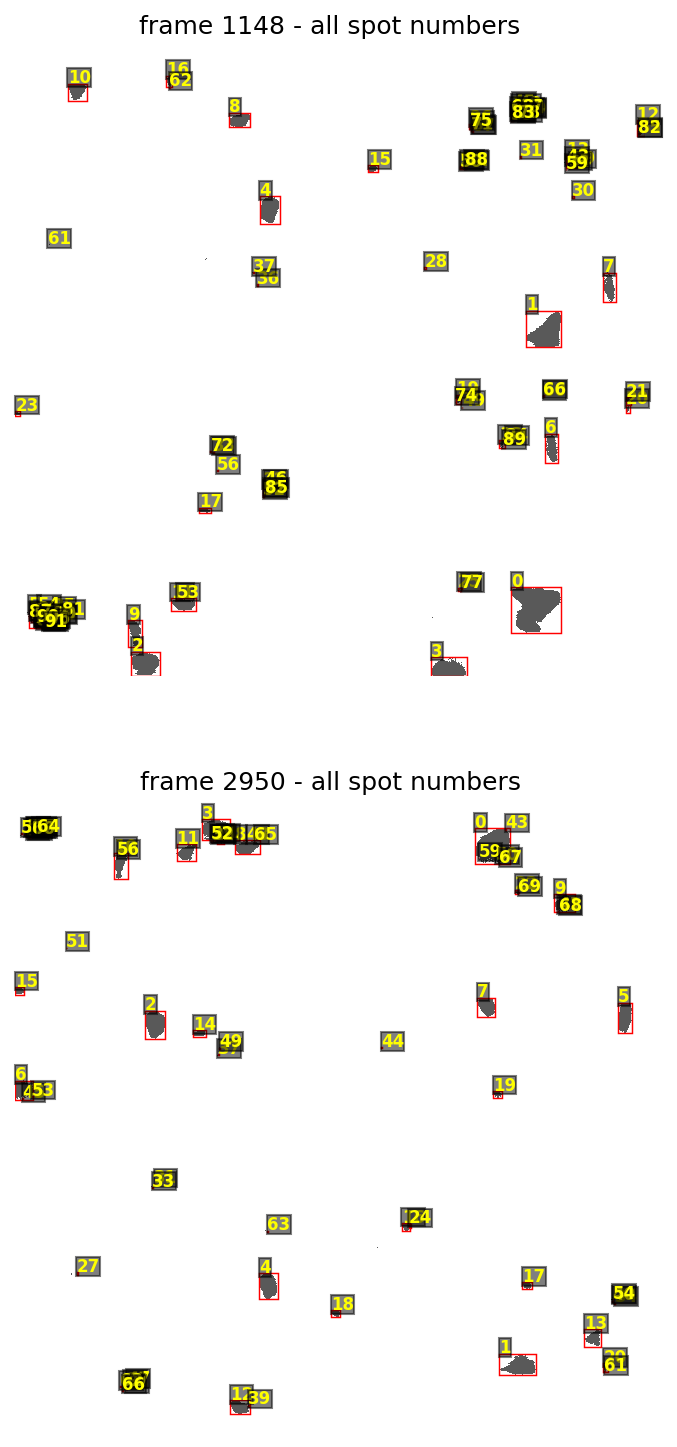

frame  n_spots
 1148       92
 2950       70


In [11]:
frames_to_show = [INPUT_FRAME] + [int(frame_idx) for frame_idx in TARGET_FRAMES]
frames_to_show = list(dict.fromkeys(frames_to_show))
bundles_by_frame = {frame_idx: frame_bundle(frame_idx) for frame_idx in frames_to_show}

fig, axes = plt.subplots(len(frames_to_show), 1, figsize=(8.0, 6.0 * len(frames_to_show)), dpi=150)
if len(frames_to_show) == 1:
    axes = [axes]

for ax, frame_idx in zip(axes, frames_to_show):
    bundle = bundles_by_frame[frame_idx]
    display, cmap, vmin, vmax = focused_seg_display(bundle["seg"])
    ax.imshow(display, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_title(f"frame {frame_idx} - all spot numbers", fontsize=12)
    for record in bundle["records"]:
        r0, c0, r1, c1 = record["bbox"]
        ax.add_patch(Rectangle((c0, r0), c1 - c0, r1 - r0, fill=False, edgecolor="red", linewidth=0.7))
        ax.text(
            c0,
            max(0, r0 - 3),
            str(record["spot_number"]),
            color="yellow",
            fontsize=8,
            fontweight="bold",
            bbox={"facecolor": "black", "alpha": 0.5, "pad": 0.15},
        )
    ax.axis("off")

plt.show()

print("frame  n_spots")
for frame_idx in frames_to_show:
    print(f"{frame_idx:5d}  {len(bundles_by_frame[frame_idx]['records']):7d}")


## 2. Define the exact sample

After checking the numbered overview above, enter the input spot number and the exact Friedel target spots here.


In [7]:
INPUT_SPOT_NUMBER = 0
FRIEDEL_TARGETS = [
    {"frame": 2948, "spot_number": 0, "name": "spot_2"},
    {"frame": 2948, "spot_number": 12, "name": "spot_1"},
]

## 3. Focused sample preview

This view highlights only the spots that belong to the exact sample you selected.


## 4. Build the exact sample you want

This uses:

- input crop from `INPUT_FRAME / INPUT_SPOT_NUMBER`
- target crops from the exact `FRIEDEL_TARGETS` list


In [8]:
frames_needed = sorted({INPUT_FRAME, *[int(item["frame"]) for item in FRIEDEL_TARGETS]})
for frame_idx in frames_needed:
    bundles_by_frame.setdefault(frame_idx, frame_bundle(frame_idx))

input_bundle = bundles_by_frame[INPUT_FRAME]
input_record = record_by_spot_number(input_bundle["records"], INPUT_SPOT_NUMBER)
input_crop = crop_from_record(
    input_bundle["raw"],
    input_bundle["seg"],
    input_record,
    crop_size=CROP_SIZE,
    fit_margin_fraction=FIT_MARGIN_FRACTION,
)
input_crop["preview_raw"] = input_crop["raw"].copy()
input_crop["preview_mask"] = input_crop["mask"].copy()

target_crops = []
for item in FRIEDEL_TARGETS:
    bundle = bundles_by_frame[item["frame"]]
    record = record_by_spot_number(bundle["records"], item["spot_number"])
    crop = crop_from_record(
        bundle["raw"],
        bundle["seg"],
        record,
        crop_size=CROP_SIZE,
        fit_margin_fraction=TARGET_FIT_MARGIN_FRACTION,
    )
    if FLIP_GROUND_TRUTH_HORIZONTALLY:
        crop["raw"] = np.fliplr(crop["raw"]).astype(np.float32, copy=False)
        crop["signal_raw"] = np.fliplr(crop["signal_raw"])
        crop["signal"] = np.fliplr(crop["signal"])
        crop["mask"] = np.fliplr(crop["mask"])
    crop["frame"] = int(item["frame"])
    crop["name"] = str(item["name"])
    crop["alignment_shift_rc"] = np.array([0, 0], dtype=np.int32)
    crop["preview_raw"] = crop["raw"].copy()
    crop["preview_mask"] = crop["mask"].copy()
    target_crops.append(crop)

if ALIGN_GROUND_TRUTH_TO_INPUT and len(target_crops) >= 2:
    target_centers = split_input_mask_centers(input_crop["mask"])
    aligned_crops = []
    for idx, crop in enumerate(target_crops):
        center_idx = min(idx, len(target_centers) - 1)
        aligned = align_target_to_center(crop, target_centers[center_idx])
        aligned["preview_raw"] = crop.get("preview_raw", crop["raw"]).copy()
        aligned["preview_mask"] = crop.get("preview_mask", crop["mask"]).copy()
        aligned_crops.append(aligned)
    target_crops = aligned_crops
else:
    target_centers = None

target_crops = pad_target_crops(target_crops, input_crop, target_count=PAD_TARGETS_TO_COUNT)

all_crops_for_normalization = [input_crop] + target_crops
shared_scale = shared_normalization_scale(all_crops_for_normalization)
apply_shared_normalization(all_crops_for_normalization, shared_scale)

if BLACK_OUT_INPUT_BACKGROUND:
    input_crop["image"] = input_crop["signal"].copy()
else:
    input_crop["image"] = input_crop["raw"].copy()
input_crop["preview_image"] = input_crop["image"].copy()

for crop in target_crops:
    if BLACK_OUT_TARGET_BACKGROUND:
        crop["image"] = crop["signal"].copy()
    else:
        crop["image"] = crop["raw"].copy()
    crop["preview_image"] = crop["image"].copy()

print("Input sample")
print(f"  frame={INPUT_FRAME}, spot={INPUT_SPOT_NUMBER}")
print(f"  shared normalization scale={shared_scale:.6g} ({JOINT_NORMALIZATION_SCOPE})")
print("Ground-truth targets")
for crop in target_crops:
    print(
        f"  {crop['name']}: frame={crop['frame']}, spot={crop['spot_number']}, "    )
if target_centers is not None:
    print("  fitted input mask centers:", target_centers)


Input sample
  frame=1148, spot=0
  shared normalization scale=738 (sample)
Ground-truth targets
  spot_2: frame=2948, spot=0, 
  spot_1: frame=2948, spot=12, 
  fitted input mask centers: [[49.786633 69.701355]
 [86.81261  54.57175 ]]


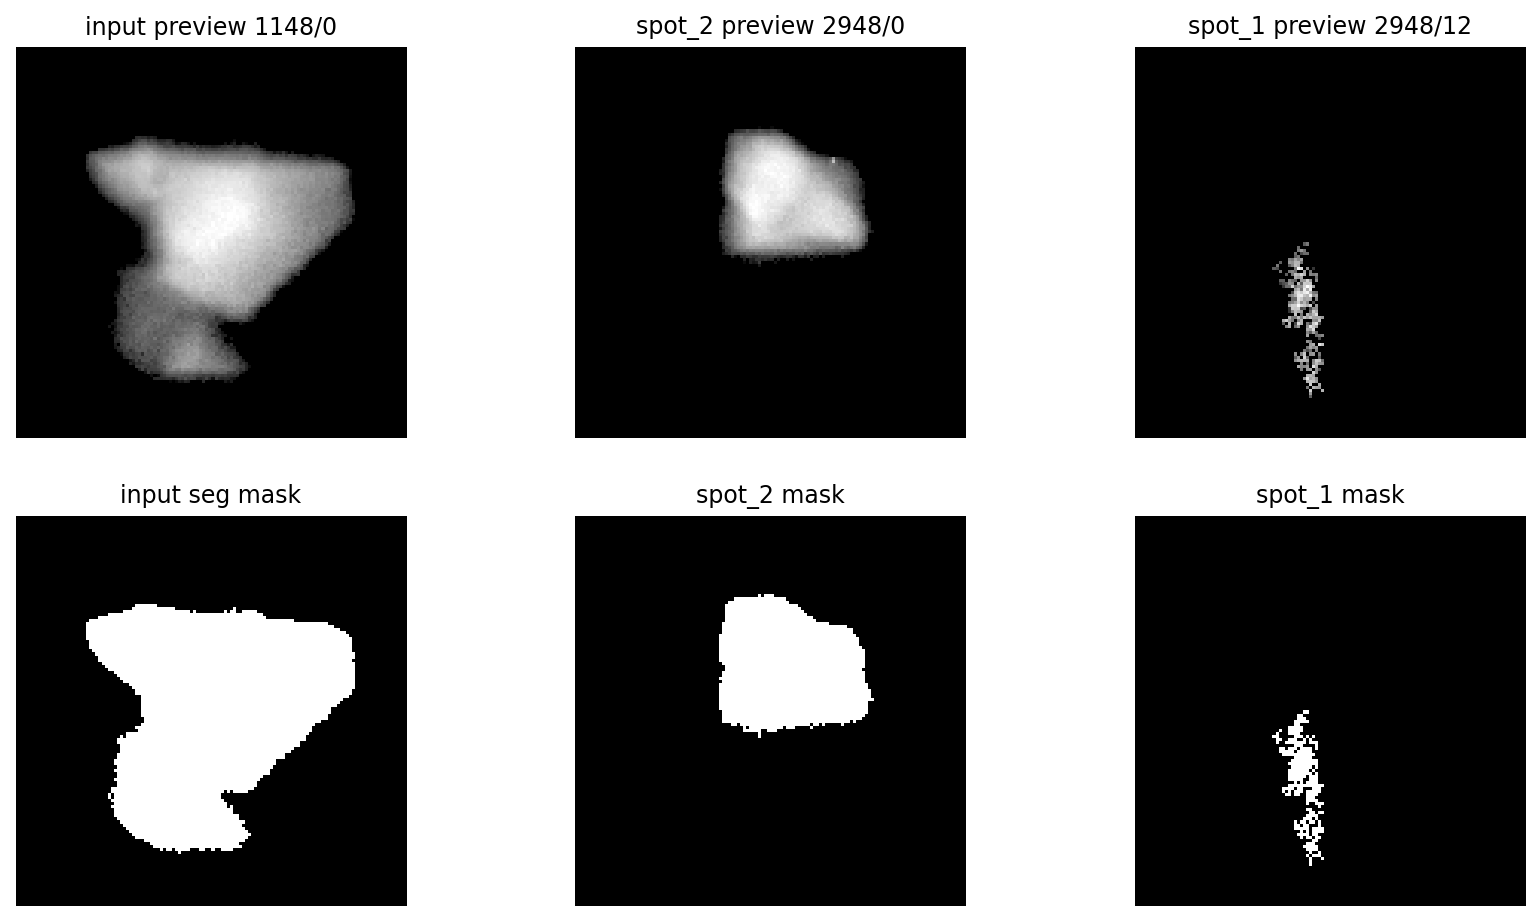

Saved preview PDF to ../data/test_friedel_crops/preview_pdfs/IN718_twins_input_1148_spot_000_preview.pdf
Preview note: raw-frame orientation now matches spot_browser. This figure uses PREVIEW_BACKGROUND_MODE for display, so crop orientation and size are unchanged while contrast still depends on the selected preview mode.


In [9]:
n_targets = len(target_crops)
fig, axes = plt.subplots(2, n_targets + 1, figsize=(4.4 * (n_targets + 1), 7.2), dpi=155)

preview_mode = PREVIEW_BACKGROUND_MODE
SAVE_PREVIEW_PDF = True

input_view, input_kwargs = preview_intensity_panel(input_crop, mode=preview_mode)
axes[0, 0].imshow(input_view, **input_kwargs)
axes[0, 0].set_title(f"input preview {INPUT_FRAME}/{INPUT_SPOT_NUMBER}", fontsize=11)
axes[1, 0].imshow(input_crop["mask"], cmap="gray", interpolation="nearest", vmin=0, vmax=1)
axes[1, 0].set_title("input seg mask", fontsize=11)
for col, crop in enumerate(target_crops, start=1):
    crop_view, crop_kwargs = preview_intensity_panel(crop, mode=preview_mode)
    axes[0, col].imshow(crop_view, **crop_kwargs)
    axes[0, col].set_title(f"{crop['name']} preview {crop['frame']}/{crop['spot_number']}", fontsize=11)
    axes[1, col].imshow(crop["mask"], cmap="gray", interpolation="nearest", vmin=0, vmax=1)
    axes[1, col].set_title(f"{crop['name']} mask", fontsize=11)

for ax in axes.flat:
    ax.axis("off")

preview_pdf_path = PREVIEW_PDF_DIR / f"{SCAN}_input_{INPUT_FRAME:04d}_spot_{INPUT_SPOT_NUMBER:03d}_preview.pdf"
if SAVE_PREVIEW_PDF:
    PREVIEW_PDF_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(preview_pdf_path, bbox_inches="tight")

plt.show()

if SAVE_PREVIEW_PDF:
    print(f"Saved preview PDF to {preview_pdf_path}")
print("Preview note: raw-frame orientation now matches spot_browser. This figure uses PREVIEW_BACKGROUND_MODE for display, so crop orientation and size are unchanged while contrast still depends on the selected preview mode.")


## 5. Export to `.h5`

This export includes a compact augmentation-like structure:

- `image`: the overlapping input crop
- `spot_images`: stacked target intensities
- `spot_masks`: stacked target masks

It also stores separate named datasets for readability.


In [536]:
DO_EXPORT = True
OVERWRITE = True


EXPORT_NAME = f"{SCAN}_input_{INPUT_FRAME:04d}_spot_{INPUT_SPOT_NUMBER:03d}.h5"

export_path = EXPORT_DIR / EXPORT_NAME
print(f"Export path: {export_path}")

if DO_EXPORT:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    if export_path.exists() and not OVERWRITE:
        raise FileExistsError(f"{export_path} already exists. Set OVERWRITE = True to replace it.")

    spot_images = np.stack([crop["image"].astype(np.float32) for crop in target_crops], axis=0)
    spot_masks = np.stack([crop["mask"].astype(np.uint8) for crop in target_crops], axis=0)

    tmp_path = export_path.with_suffix(".tmp.h5")
    if tmp_path.exists():
        tmp_path.unlink()

    with h5py.File(tmp_path, "w") as f:
        f.attrs["scan"] = SCAN
        f.attrs["rotation_k_90deg"] = int(DISPLAY_ROTATE_K)
        f.attrs["crop_size"] = int(CROP_SIZE)
        f.attrs["raw_path"] = str(RAW_PATH)
        f.attrs["seg_path"] = str(SEG_PATH)
        f.attrs["input_frame"] = int(INPUT_FRAME)
        f.attrs["input_spot_number"] = int(INPUT_SPOT_NUMBER)
        f.attrs["flip_ground_truth_horizontally"] = bool(FLIP_GROUND_TRUTH_HORIZONTALLY)
        f.attrs["black_out_input_background"] = bool(BLACK_OUT_INPUT_BACKGROUND)
        f.attrs["black_out_target_background"] = bool(BLACK_OUT_TARGET_BACKGROUND)
        f.attrs["normalize_intensity_with_mask"] = bool(NORMALIZE_INTENSITY_WITH_MASK)
        f.attrs["joint_normalization_scope"] = JOINT_NORMALIZATION_SCOPE
        f.attrs["shared_normalization_scale"] = float(shared_scale)
        f.attrs["input_fit_margin_fraction"] = float(FIT_MARGIN_FRACTION)
        f.attrs["target_fit_margin_fraction"] = float(TARGET_FIT_MARGIN_FRACTION)
        f.attrs["min_mask_intensity"] = float(MIN_MASK_INTENSITY)
        f.attrs["align_ground_truth_to_input"] = bool(ALIGN_GROUND_TRUTH_TO_INPUT)
        f.attrs["target_frames"] = np.asarray([crop["frame"] for crop in target_crops], dtype=np.int32)
        f.attrs["target_spot_numbers"] = np.asarray([crop["spot_number"] for crop in target_crops], dtype=np.int32)
        f.attrs["target_names"] = np.asarray([crop["name"].encode("utf-8") for crop in target_crops])
        f.attrs["target_alignment_shift_rc"] = np.stack([crop["alignment_shift_rc"] for crop in target_crops], axis=0)

        f.create_dataset("image", data=input_crop["image"].astype(np.float32), compression="gzip")
        f.create_dataset("input_mask", data=input_crop["mask"].astype(np.uint8), compression="gzip")
        f.create_dataset("spot_images", data=spot_images, compression="gzip")
        f.create_dataset("spot_masks", data=spot_masks, compression="gzip")

        input_group = f.create_group("input")
        input_group.attrs["frame"] = int(INPUT_FRAME)
        input_group.attrs["spot_number"] = int(INPUT_SPOT_NUMBER)
        input_group.attrs["bbox"] = input_crop["bbox"]
        input_group.attrs["centroid_rc"] = input_crop["centroid_rc"]
        input_group.attrs["pixels"] = int(input_crop["pixels"])

        for idx, crop in enumerate(target_crops):
            g = f.create_group(f"target_{idx + 1}")
            g.attrs["name"] = crop["name"]
            g.attrs["frame"] = int(crop["frame"])
            g.attrs["spot_number"] = int(crop["spot_number"])
            g.attrs["bbox"] = crop["bbox"]
            g.attrs["centroid_rc"] = crop["centroid_rc"]
            g.attrs["pixels"] = int(crop["pixels"])
            g.attrs["alignment_shift_rc"] = crop["alignment_shift_rc"]
            g.create_dataset("intensity", data=crop["image"].astype(np.float32), compression="gzip")
            g.create_dataset("mask", data=crop["mask"].astype(np.uint8), compression="gzip")

    if export_path.exists():
        export_path.unlink()
    tmp_path.rename(export_path)
    print(f"Wrote {export_path}")
else:
    print("Dry run only. Set DO_EXPORT = True when you want the HDF5 written.")


Export path: ../data/test_friedel_crops/IN718_twins_input_0150_spot_000.h5
Wrote ../data/test_friedel_crops/IN718_twins_input_0150_spot_000.h5
